In [3]:
import pandas as pd
df = pd.read_csv("/content/cardio_data_processed.csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [4]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.columns)
print(df.isnull().sum()/len(df)*100)

(68205, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          682

In [5]:
df=df.drop(['bp_category_encoded','age','id'],axis=1)

In [6]:
x=df.drop(['cardio'],axis=1)
y=df['cardio']

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['bp_category']=le.fit_transform(x['bp_category'])

In [8]:
from sklearn.model_selection import train_test_split
x_train_final,x_test,y_train_final,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
print(x_train_final.shape)
print(x_test.shape)


(54564, 13)
(13641, 13)


In [9]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

In [10]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import numpy as np
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
from imblearn.combine import SMOTETomek
smote=SMOTETomek(random_state=42)

In [11]:
from catboost import CatBoostClassifier
def objective(trial):
  params={
        "learning_rate": trial.suggest_float("learning_rate",0.005,0.15,log=True
        ),

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg",1,20
        ),

        "random_strength": trial.suggest_float("random_strength",0,5
        ),

        "bagging_temperature": trial.suggest_float("bagging_temperature",0,5
        ),

        "border_count": trial.suggest_int("border_count",64,255
        ),
        "grow_policy": trial.suggest_categorical( "grow_policy",["SymmetricTree", "Depthwise", "Lossguide"]
        ),

        "leaf_estimation_iterations": trial.suggest_int("leaf_estimation_iterations",1,10
        ),
      "loss_function":"Logloss",
      "eval_metric":"F1",
      "random_seed":42,
      "verbose":0
      }
  scores=[]
  for train,valid in skf.split(x_train_final,y_train_final):
      x_train=x_train_final.iloc[train]
      x_valid=x_train_final.iloc[valid]
      y_train=y_train_final.iloc[train]
      y_valid=y_train_final.iloc[valid]
      x_train,y_train=smote.fit_resample(x_train,y_train)
      model=CatBoostClassifier(**params)
      model.fit(x_train,y_train,eval_set=[(x_valid,y_valid)],early_stopping_rounds=100,verbose=False)
      pred=model.predict(x_valid)
      score=f1_score(y_valid,pred)
      scores.append(score)
  return np.mean(scores)

study_cb=optuna.create_study(direction="maximize",sampler=TPESampler(seed=44),pruner=MedianPruner())
study_cb.optimize(objective,n_trials=5,show_progress_bar=True)



[I 2026-07-15 12:36:17,273] A new study created in memory with name: no-name-d6b69a48-fe95-4409-b62b-34e0120cfd9c


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-07-15 12:36:52,680] Trial 0 finished with value: 0.7227551520221722 and parameters: {'learning_rate': 0.08553287821710791, 'l2_leaf_reg': 2.9911259830275254, 'random_strength': 3.723202408397589, 'bagging_temperature': 1.8025041812814284, 'border_count': 132, 'grow_policy': 'SymmetricTree', 'leaf_estimation_iterations': 6}. Best is trial 0 with value: 0.7227551520221722.
[I 2026-07-15 12:37:40,645] Trial 1 finished with value: 0.7231305544391076 and parameters: {'learning_rate': 0.055968632950984774, 'l2_leaf_reg': 19.24999827890768, 'random_strength': 2.283105544694686, 'bagging_temperature': 2.138257605308045, 'border_count': 85, 'grow_policy': 'Depthwise', 'leaf_estimation_iterations': 9}. Best is trial 1 with value: 0.7231305544391076.
[I 2026-07-15 12:38:21,021] Trial 2 finished with value: 0.722389190267249 and parameters: {'learning_rate': 0.04506058081611193, 'l2_leaf_reg': 5.062671430481562, 'random_strength': 3.184160069034196, 'bagging_temperature': 0.695731259924517

In [12]:
from lightgbm import LGBMClassifier
import lightgbm as lgb
def objective(trial):
  params={
      "n_estimators":trial.suggest_int("n_estimators",500,1500),
      "learning_rate":trial.suggest_float("learning_rate",0.001,0.3,log=True),
      "max_depth":trial.suggest_int("max_depth",4,10),
      "num_leaves":trial.suggest_int("num_leaves",30,200),
      "min_child_samples":trial.suggest_int("min_child_samples",20,100),
      "subsample":trial.suggest_float("subsample",0.6,1.0),
      "colsample_bytree":trial.suggest_float("colsample_bytree",0.6,1.0),
      "reg_alpha":trial.suggest_float("reg_alpha",1e-8,10,log=True),
      "reg_lambda":trial.suggest_float("reg_lambda",1e-8,10,log=True),
      "random_state":42,
      "n_jobs":-1,
      "verbosity": -1
      }

  scores=[]
  for train,valid in skf.split(x_train_final,y_train_final):
      x_train=x_train_final.iloc[train]
      x_valid=x_train_final.iloc[valid]
      y_train=y_train_final.iloc[train]
      y_valid=y_train_final.iloc[valid]
      x_train,y_train=smote.fit_resample(x_train,y_train)
      model=LGBMClassifier(**params)
      model.fit(x_train,y_train,eval_set=[(x_valid,y_valid)],callbacks=[lgb.early_stopping(100,verbose=False)])
      pred=model.predict(x_valid)
      score=f1_score(y_valid,pred)
      scores.append(score)
  return np.mean(scores)
study_lg=optuna.create_study(direction="maximize",sampler=TPESampler(seed=44),pruner=MedianPruner())
study_lg.optimize(objective,n_trials=5,show_progress_bar=True)

[I 2026-07-15 12:39:32,728] A new study created in memory with name: no-name-ae7830b8-4fbf-403b-a3ff-e086343cb21f


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-07-15 12:40:58,152] Trial 0 finished with value: 0.7200124297488963 and parameters: {'n_estimators': 1335, 'learning_rate': 0.0018179948873581753, 'max_depth': 9, 'num_leaves': 91, 'min_child_samples': 49, 'subsample': 0.8436953522472607, 'colsample_bytree': 0.7575118204353005, 'reg_alpha': 4.804558533789276e-05, 'reg_lambda': 0.0003882591382732714}. Best is trial 0 with value: 0.7200124297488963.
[I 2026-07-15 12:41:16,907] Trial 1 finished with value: 0.7189396255947503 and parameters: {'n_estimators': 1210, 'learning_rate': 0.23951897703728056, 'max_depth': 7, 'num_leaves': 103, 'min_child_samples': 29, 'subsample': 0.6871595477386097, 'colsample_bytree': 0.982988827627167, 'reg_alpha': 3.091409118798695, 'reg_lambda': 0.8638106026774913}. Best is trial 0 with value: 0.7200124297488963.
[I 2026-07-15 12:42:09,699] Trial 2 finished with value: 0.7207301124790383 and parameters: {'n_estimators': 1147, 'learning_rate': 0.00338586771957617, 'max_depth': 8, 'num_leaves': 53, 'min

In [13]:
from xgboost import XGBClassifier
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",300,1500,step=100
        ),

        "max_depth": trial.suggest_int("max_depth",3,12
        ),

        "learning_rate": trial.suggest_float("learning_rate",0.005,0.2,log=True
        ),

        "min_child_weight": trial.suggest_int("min_child_weight",1,10
        ),

        "subsample": trial.suggest_float("subsample",0.6,1.0
        ),

        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0
        ),

        "gamma": trial.suggest_float("gamma",0,5
        ),

        "reg_alpha": trial.suggest_float("reg_alpha",1e-8,10,log=True
        ),

        "reg_lambda": trial.suggest_float("reg_lambda",1e-8,10,log=True
        ),

        "random_state": 44,
        "n_jobs": -1,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist"
    }

    scores=[]
    for train,valid in skf.split(x_train_final,y_train_final):
        x_train=x_train_final.iloc[train]
        x_valid=x_train_final.iloc[valid]
        y_train=y_train_final.iloc[train]
        y_valid=y_train_final.iloc[valid]
        x_train,y_train=smote.fit_resample(x_train,y_train)
        model=XGBClassifier(**params)
        model.fit(x_train,y_train,eval_set=[(x_valid,y_valid)],verbose=False)
        pred=model.predict(x_valid)
        score=f1_score(y_valid,pred)
        scores.append(score)
    return np.mean(scores)

study_xg = optuna.create_study(direction="maximize",sampler=TPESampler(seed=44),pruner=MedianPruner())
study_xg.optimize(objective,n_trials=5,show_progress_bar=True)

[I 2026-07-15 12:43:01,339] A new study created in memory with name: no-name-acfd42ce-b9ab-4c09-b92f-a2c446157b7b


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-07-15 12:43:48,534] Trial 0 finished with value: 0.7194289923355303 and parameters: {'n_estimators': 1300, 'max_depth': 4, 'learning_rate': 0.07797021431500437, 'min_child_weight': 4, 'subsample': 0.7437243351232288, 'colsample_bytree': 0.8436953522472607, 'gamma': 1.9688977554412568, 'reg_alpha': 4.804558533789276e-05, 'reg_lambda': 0.0003882591382732714}. Best is trial 0 with value: 0.7194289923355303.
[I 2026-07-15 12:44:44,234] Trial 1 finished with value: 0.721869040556167 and parameters: {'n_estimators': 1200, 'max_depth': 12, 'learning_rate': 0.02694662720724606, 'min_child_weight': 5, 'subsample': 0.6453854804479882, 'colsample_bytree': 0.6871595477386097, 'gamma': 4.787360345339587, 'reg_alpha': 3.091409118798695, 'reg_lambda': 0.8638106026774913}. Best is trial 1 with value: 0.721869040556167.
[I 2026-07-15 12:45:31,018] Trial 2 finished with value: 0.7185011849061047 and parameters: {'n_estimators': 1100, 'max_depth': 5, 'learning_rate': 0.05238574141451133, 'min_chi

In [14]:
x_train_final,y_train_final=smote.fit_resample(x_train_final,y_train_final)

In [15]:
print(study_cb.best_value)
print(study_cb.best_params)

0.7231305544391076
{'learning_rate': 0.055968632950984774, 'l2_leaf_reg': 19.24999827890768, 'random_strength': 2.283105544694686, 'bagging_temperature': 2.138257605308045, 'border_count': 85, 'grow_policy': 'Depthwise', 'leaf_estimation_iterations': 9}


In [16]:
print(study_lg.best_value)
print(study_lg.best_params)

0.7207301124790383
{'n_estimators': 1147, 'learning_rate': 0.00338586771957617, 'max_depth': 8, 'num_leaves': 53, 'min_child_samples': 57, 'subsample': 0.9495452740625273, 'colsample_bytree': 0.7033801223468295, 'reg_alpha': 0.009630744910641191, 'reg_lambda': 0.5808567283006757}


In [17]:
print(study_xg.best_value)
print(study_xg.best_params)

0.721869040556167
{'n_estimators': 1200, 'max_depth': 12, 'learning_rate': 0.02694662720724606, 'min_child_weight': 5, 'subsample': 0.6453854804479882, 'colsample_bytree': 0.6871595477386097, 'gamma': 4.787360345339587, 'reg_alpha': 3.091409118798695, 'reg_lambda': 0.8638106026774913}


In [18]:
best_model_cb=CatBoostClassifier(**study_cb.best_params,random_state=42)

In [19]:
best_model_lg=LGBMClassifier(**study_lg.best_params,random_state=42,n_jobs=1)

In [20]:
best_model_xg=XGBClassifier(**study_xg.best_params,random_state=42,n_jobs=1)

In [21]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(
        y_test,
        prob[:, 1]
    )
    print("=" * 50)
    print(f"Model     : {model.__class__.__name__}")
    print("=" * 50)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_test, pred, zero_division=0))
    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, pred))
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

In [22]:
result_cb=evaluate_model(best_model_cb,x_train_final,y_train_final,x_test,y_test)

0:	learn: 0.6694614	total: 21.3ms	remaining: 21.3s
1:	learn: 0.6490589	total: 42.4ms	remaining: 21.1s
2:	learn: 0.6310528	total: 63.1ms	remaining: 21s
3:	learn: 0.6148587	total: 83.9ms	remaining: 20.9s
4:	learn: 0.6015326	total: 104ms	remaining: 20.8s
5:	learn: 0.5896587	total: 125ms	remaining: 20.7s
6:	learn: 0.5787701	total: 145ms	remaining: 20.6s
7:	learn: 0.5687076	total: 166ms	remaining: 20.6s
8:	learn: 0.5606451	total: 187ms	remaining: 20.6s
9:	learn: 0.5530246	total: 208ms	remaining: 20.6s
10:	learn: 0.5461183	total: 233ms	remaining: 20.9s
11:	learn: 0.5396860	total: 257ms	remaining: 21.1s
12:	learn: 0.5341044	total: 278ms	remaining: 21.1s
13:	learn: 0.5292924	total: 302ms	remaining: 21.2s
14:	learn: 0.5248244	total: 323ms	remaining: 21.2s
15:	learn: 0.5211014	total: 344ms	remaining: 21.1s
16:	learn: 0.5176572	total: 365ms	remaining: 21.1s
17:	learn: 0.5148521	total: 386ms	remaining: 21s
18:	learn: 0.5122820	total: 407ms	remaining: 21s
19:	learn: 0.5101090	total: 428ms	remaining

In [23]:
result_lg=evaluate_model(best_model_lg,x_train_final,y_train_final,x_test,y_test)

Model     : LGBMClassifier
Accuracy  : 0.7363
Precision : 0.7373
Recall    : 0.7363
F1 Score  : 0.7358
ROC AUC   : 0.8017

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6907
           1       0.75      0.70      0.72      6734

    accuracy                           0.74     13641
   macro avg       0.74      0.74      0.74     13641
weighted avg       0.74      0.74      0.74     13641


Confusion Matrix

[[5357 1550]
 [2047 4687]]


In [24]:
result_xg=evaluate_model(best_model_xg,x_train_final,y_train_final,x_test,y_test)

Model     : XGBClassifier
Accuracy  : 0.7376
Precision : 0.7386
Recall    : 0.7376
F1 Score  : 0.7372
ROC AUC   : 0.8022

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.78      0.75      6907
           1       0.75      0.70      0.72      6734

    accuracy                           0.74     13641
   macro avg       0.74      0.74      0.74     13641
weighted avg       0.74      0.74      0.74     13641


Confusion Matrix

[[5361 1546]
 [2033 4701]]


In [26]:
import mlflow
import mlflow.sklearn
metrics = {
    "Accuracy": result_cb["Accuracy"],
    "Precision": result_cb["Precision"],
    "Recall": result_cb["Recall"],
    "F1": result_cb["F1"],
    "ROC_AUC": result_cb["ROC_AUC"]
}

def log_to_mlflow(experiment_name,run_name,model,best_params,metrics):
    mlflow.set_experiment(experiment_name)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(best_params)
        mlflow.log_metrics(metrics)
        mlflow.catboost.log_model(
                cb_model=model,
                name="model"

        )
    print(f"✅ {run_name} logged successfully!")
def log_xgboost_to_mlflow(experiment_name, run_name, model, best_params, metrics):

    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(best_params)
        mlflow.log_metrics(metrics)

        mlflow.xgboost.log_model(
            xgb_model=model,
            name="model"
        )

    print(f"✅ {run_name} logged successfully!")
def log_lightgbm_to_mlflow(experiment_name, run_name, model, best_params, metrics):

    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(best_params)
        mlflow.log_metrics(metrics)

        mlflow.lightgbm.log_model(
            lgb_model=model,
            name="model"
        )

    print(f"✅ {run_name} logged successfully!")

In [27]:
log_to_mlflow(experiment_name="CatBoost_Classifier",run_name="CatBoost_Optuna",model=best_model_cb,best_params=study_cb.best_params,metrics=metrics)

2026/07/15 12:51:23 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/15 12:51:23 INFO mlflow.store.db.utils: Updating database tables
2026/07/15 12:51:28 INFO mlflow.tracking.fluent: Experiment with name 'CatBoost_Classifier' does not exist. Creating a new experiment.


✅ CatBoost_Optuna logged successfully!


In [28]:
log_lightgbm_to_mlflow(experiment_name="LightGBM_Classifier",run_name="LightGBM_Optuna",model=best_model_lg,best_params=study_lg.best_params,metrics=metrics)

2026/07/15 12:51:39 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Classifier' does not exist. Creating a new experiment.


✅ LightGBM_Optuna logged successfully!


In [29]:
log_xgboost_to_mlflow(experiment_name="XGBoost_Classifier",run_name="XGBoost_Optuna",model=best_model_xg,best_params=study_xg.best_params,metrics=metrics)

2026/07/15 12:51:58 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Classifier' does not exist. Creating a new experiment.


✅ XGBoost_Optuna logged successfully!


In [30]:
feature_importance_cb=pd.DataFrame({
    "Features":x_train_final.columns,
    "Importance":best_model_cb.feature_importances_
})

feature_importance_cb=feature_importance_cb.sort_values("Importance",ascending=False)
feature_importance_cb.to_csv("feature_importance_cb.csv")
feature_importance_cb.head()

,Features,Importance
3,ap_hi,57.321537
10,age_years,13.042099
5,cholesterol,5.566586
11,bmi,5.102696
2,weight,4.844691


In [31]:
feature_importance_lg=pd.DataFrame({
    "Features":x_train_final.columns,
    "Importance":best_model_lg.feature_importances_
})

feature_importance_lg=feature_importance_lg.sort_values("Importance",ascending=False)
feature_importance_lg.to_csv("feature_importance_lg.csv")
feature_importance_lg.head()

,Features,Importance
11,bmi,11700
10,age_years,9197
2,weight,8278
1,height,6605
3,ap_hi,5500


In [32]:
feature_importance_xg=pd.DataFrame({
    "Features":x_train_final.columns,
    "Importance":best_model_xg.feature_importances_
})

feature_importance_xg=feature_importance_xg.sort_values("Importance",ascending=False)
feature_importance_xg.to_csv("feature_importance_xg.csv")
feature_importance_xg.head()

,Features,Importance
3,ap_hi,0.407370
4,ap_lo,0.225623
5,cholesterol,0.083120
12,bp_category,0.082934
10,age_years,0.076370


In [33]:
import matplotlib.pyplot as plt

def feature_imp_plot(feature_importance,model_name):
    top=feature_importance.head(20)
    plt.figure(figsize=(10,5))
    plt.barh(top['Features'],top['Importance'])
    plt.gca().invert_yaxis()
    plt.title("Top Features")
    plt.tight_layout()
    plt.savefig(f"feature_importance{model_name}.png")
    plt.show()

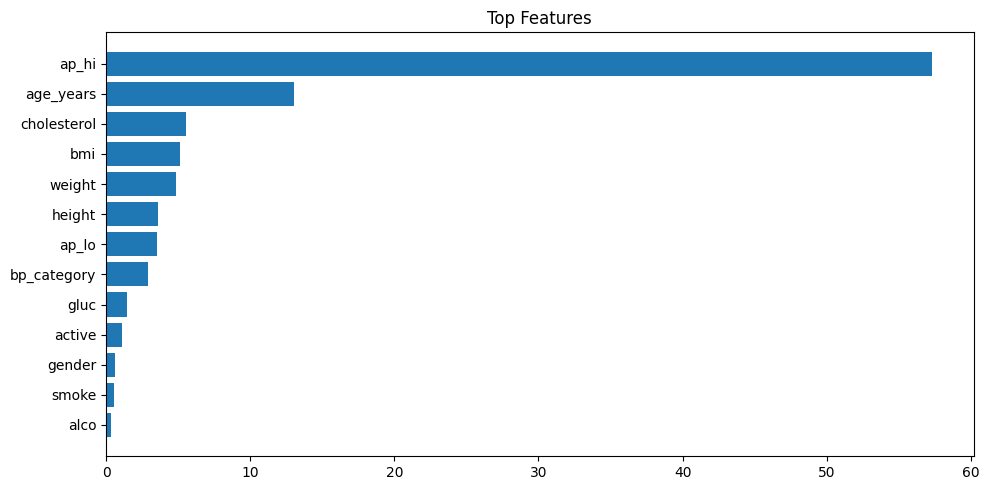

In [34]:
feature_imp_plot(feature_importance_cb,model_name="model_cb")

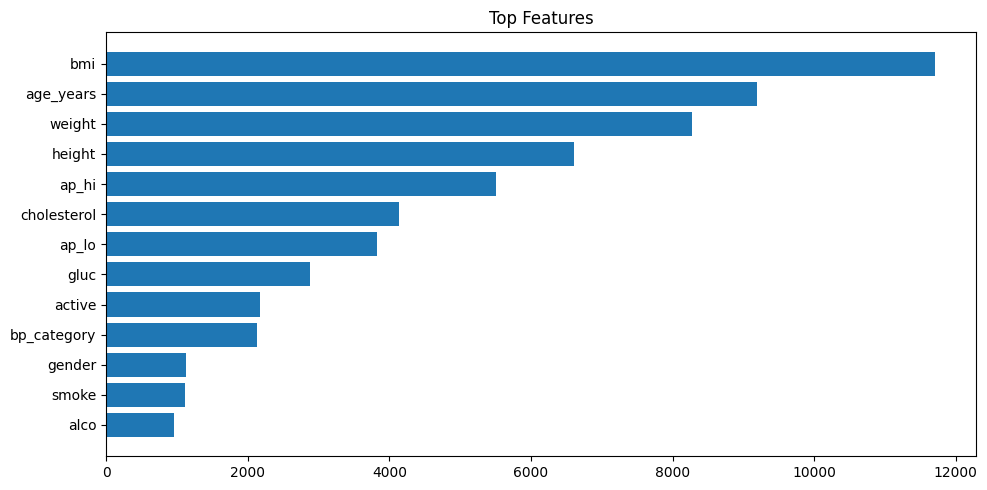

In [35]:
feature_imp_plot(feature_importance_lg,model_name="model_lg")

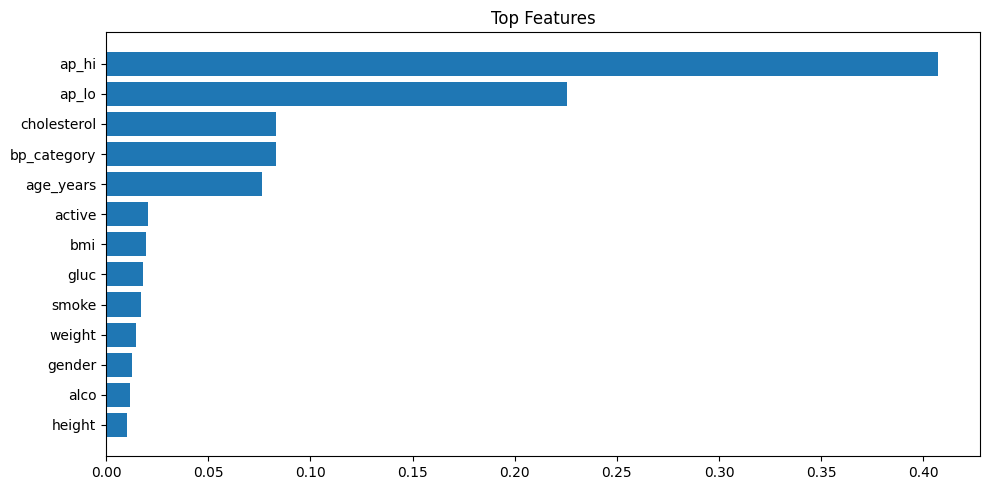

In [36]:
feature_imp_plot(feature_importance_xg,model_name="model_xg")

In [37]:
metrics_cb = {
    "Accuracy": result_cb["Accuracy"],
    "Precision": result_cb["Precision"],
    "Recall": result_cb["Recall"],
    "F1": result_cb["F1"],
    "ROC_AUC": result_cb["ROC_AUC"]
}

In [38]:
metrics_lg = {
    "Accuracy": result_lg["Accuracy"],
    "Precision": result_lg["Precision"],
    "Recall": result_lg["Recall"],
    "F1": result_lg["F1"],
    "ROC_AUC": result_lg["ROC_AUC"]
}

In [39]:
metrics_xg = {
    "Accuracy": result_xg["Accuracy"],
    "Precision": result_xg["Precision"],
    "Recall": result_xg["Recall"],
    "F1": result_xg["F1"],
    "ROC_AUC": result_xg["ROC_AUC"]
}

In [40]:
import joblib

def save_model_artifacts(
    model,
    best_params,
    metrics,
    model_name
):
    joblib.dump(model, f"{model_name}.pkl")
    joblib.dump(best_params, f"{model_name}_best_params.pkl")
    joblib.dump(metrics, f"{model_name}_metrics.pkl")


In [41]:
save_model_artifacts(
    model=best_model_cb,
    best_params=study_cb.best_params,
    metrics=metrics_cb,
    model_name="catboost"
)

In [42]:
save_model_artifacts(
    model=best_model_lg,
    best_params=study_lg.best_params,
    metrics=metrics,
    model_name="lightgbm"
)

In [43]:
save_model_artifacts(
    model=best_model_xg,
    best_params=study_xg.best_params,
    metrics=metrics,
    model_name="xgbost"
)

In [44]:
models = {

    "XGBoost": best_model_xg,

    "LightGBM": best_model_lg,

    "CatBoost": best_model_cb

}

In [45]:
import time
import numpy as np

results = []

for name, model in models.items():

    start = time.time()

    pred = model.predict(x_test)

    inference_time = time.time() - start

    if hasattr(model, "predict_proba"):

        prob = model.predict_proba(x_test)[:,0]

        if len(np.unique(y_test)) == 2:

            roc_auc = roc_auc_score(y_test, prob)
        else:

            roc_auc = roc_auc_score(
                y_test,
                prob,

            )
    else:

        roc_auc = np.nan

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(
            y_test,
            pred,
            average="weighted"
        ),

        "Recall": recall_score(
            y_test,
            pred,
            average="weighted"
        ),

        "F1 Score": f1_score(
            y_test,
            pred,
            average="weighted"
        ),

        "ROC AUC": roc_auc,

        "Inference Time (sec)": inference_time

    })

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    "F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Inference Time (sec)
0,XGBoost,0.737629,0.738610,0.737629,0.737175,0.197849,0.682064
1,LightGBM,0.736310,0.737328,0.736310,0.735837,0.198256,2.354507
2,CatBoost,0.732937,0.733745,0.732937,0.732530,0.202965,0.308329


In [46]:
comparison.to_csv("model_comparison.csv",index=False)

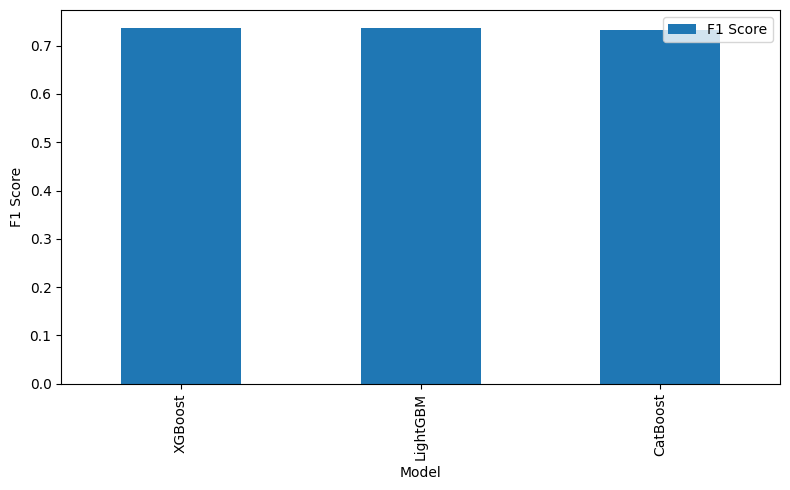

In [50]:
import matplotlib.pyplot as plt

comparison.plot(x="Model",y="F1 Score",kind="bar",figsize=(8,5))

plt.ylabel("F1 Score")

plt.tight_layout()

plt.savefig("comparision.png")

plt.show()

In [49]:
best_model_name = comparison.iloc[0]["Model"]
print("Best Model :", best_model_name)

Best Model : XGBoost
